# CHURN MODEL

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                              roc_curve, confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import shap

In [3]:
customer_features = pd.read_csv(r"C:\Users\Pavitra\Downloads\Olist_E-Commerce_Analysis\notebooks\customer_features_final.csv")
customer_features.columns

Index(['Unnamed: 0', 'customer_unique_id', 'total_orders', 'total_spend',
       'avg_order_value', 'max_order_value', 'min_order_value',
       'first_purchase', 'last_purchase', 'avg_review_score',
       'min_review_score', 'avg_delivery_days', 'pct_on_time',
       'favorite_category', 'num_categories', 'state', 'avg_freight_ratio',
       'avg_delivery_delta', 'gave_low_review', 'gave_high_review',
       'has_review', 'recency_days', 'customer_age_days',
       'avg_days_between_orders', 'has_repeat_orders', 'order_value_range',
       'spend_per_active_day', 'churned', 'is_consumable_category',
       'is_one_time_category', 'spend_tier', 'review_missing',
       'churn_probability', 'risk_tier'],
      dtype='object')

In [4]:
customer_features.head()

,Unnamed: 0,customer_unique_id,total_orders,total_spend,avg_order_value,max_order_value,min_order_value,first_purchase,last_purchase,avg_review_score,...,has_repeat_orders,order_value_range,spend_per_active_day,churned,is_consumable_category,is_one_time_category,spend_tier,review_missing,churn_probability,risk_tier
0,0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,141.90,141.90,2018-05-10 10:56:27,2018-05-10 10:56:27,5.0,...,0,141.90,141.90,0,0,1,4,0,0.109427,Low Risk
1,1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,27.19,27.19,2018-05-07 11:11:27,2018-05-07 11:11:27,4.0,...,0,27.19,27.19,0,1,0,1,0,0.022889,Low Risk
2,2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,86.22,86.22,2017-03-10 21:05:03,2017-03-10 21:05:03,3.0,...,0,86.22,86.22,1,1,0,2,0,0.848267,Critical Risk
3,3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,43.62,43.62,2017-10-12 20:29:41,2017-10-12 20:29:41,4.0,...,0,43.62,43.62,1,0,1,1,0,0.589667,Medium Risk
4,4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,196.89,196.89,2017-11-14 19:45:42,2017-11-14 19:45:42,5.0,...,0,196.89,196.89,1,0,1,4,0,0.786963,High Risk


In [5]:
customer_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93350 entries, 0 to 93349
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               93350 non-null  int64  
 1   customer_unique_id       93350 non-null  object 
 2   total_orders             93350 non-null  int64  
 3   total_spend              93350 non-null  float64
 4   avg_order_value          93350 non-null  float64
 5   max_order_value          93350 non-null  float64
 6   min_order_value          93350 non-null  float64
 7   first_purchase           93350 non-null  object 
 8   last_purchase            93350 non-null  object 
 9   avg_review_score         92747 non-null  float64
 10  min_review_score         92747 non-null  float64
 11  avg_delivery_days        93350 non-null  float64
 12  pct_on_time              93350 non-null  float64
 13  favorite_category        93350 non-null  object 
 14  num_categories        

In [6]:
# avg_freight_ratio quintiles
pd.qcut(
    customer_features['avg_freight_ratio'],
    q=5,
    duplicates='drop'
).value_counts().sort_index()

avg_freight_ratio
(-0.001, 0.103]    18670
(0.103, 0.155]     18670
(0.155, 0.215]     18679
(0.215, 0.302]     18662
(0.302, 0.955]     18669
Name: count, dtype: int64

In [7]:
# avg_delivery_delta quintiles
pd.qcut(
    customer_features['avg_delivery_delta'],
    q=5,
    duplicates='drop'
).value_counts().sort_index()

avg_delivery_delta
(-146.001, -18.0]    19531
(-18.0, -13.0]       23380
(-13.0, -10.0]       14217
(-10.0, -6.0]        18049
(-6.0, 189.0]        18173
Name: count, dtype: int64

In [8]:
features_for_model= ['total_orders', 'total_spend', 'avg_order_value','avg_review_score', 'avg_delivery_days',
       'pct_on_time', 'num_categories','customer_age_days', 'has_repeat_orders','avg_days_between_orders']

X = customer_features[features_for_model].fillna(0)
y = customer_features['churned']

print(f"Features: {len(features_for_model)}")
print(f"Samples: {len(X):,}")
print(f"Churn rate: {y.mean()*100:.1f}%")
print(f"\nClass distribution:")
print(y.value_counts())

Features: 10
Samples: 93,350
Churn rate: 58.9%

Class distribution:
churned
1    55004
0    38346
Name: count, dtype: int64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")
print(f"Train churn rate: {y_train.mean()*100:.1f}%")
print(f"Test churn rate:  {y_test.mean()*100:.1f}%")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform training
X_test_scaled  = scaler.transform(X_test)            # transform only (no fit) for test

print("Feature scaling applied")
print(f"Train scaled shape: {X_train_scaled.shape}")

Training set: 74,680 samples
Test set:     18,670 samples
Train churn rate: 58.9%
Test churn rate:  58.9%
Feature scaling applied
Train scaled shape: (74680, 10)


In [10]:
## training 3 models 

models = {'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10,min_samples_leaf=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,subsample=0.8, colsample_bytree=0.8
                            ,random_state=42, use_label_encoder=False,eval_metric='logloss', verbosity=0)}

results = {}

for name, model in models.items():
    print(f"\nTraining: {name}...")

    # Use scaled data for Logistic Regression, unscaled for trees
    X_tr = X_train_scaled if name == 'Logistic Regression' else X_train
    X_te = X_test_scaled if name == 'Logistic Regression' else X_test

    model.fit(X_tr, y_train)

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]  # probability of churn

    auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)

    results[name] = {'model': model,'y_pred': y_pred,'y_prob': y_prob,'auc': auc,'f1': report['weighted avg']['f1-score'],
                     'precision': report['1']['precision'],'recall': report['1']['recall']}

    print(f"  AUC-ROC: {auc:.4f}")
    print(f"  F1 (weighted): {report['weighted avg']['f1-score']:.4f}")
    print(f"  Precision (churn): {report['1']['precision']:.4f}")
    print(f"  Recall (churn):    {report['1']['recall']:.4f}")


Training: Logistic Regression...
  AUC-ROC: 0.6239
  F1 (weighted): 0.5555
  Precision (churn): 0.6176
  Recall (churn):    0.8905

Training: Random Forest...
  AUC-ROC: 0.6462
  F1 (weighted): 0.6014
  Precision (churn): 0.6422
  Recall (churn):    0.8261

Training: XGBoost...
  AUC-ROC: 0.6657
  F1 (weighted): 0.6221
  Precision (churn): 0.6570
  Recall (churn):    0.8159


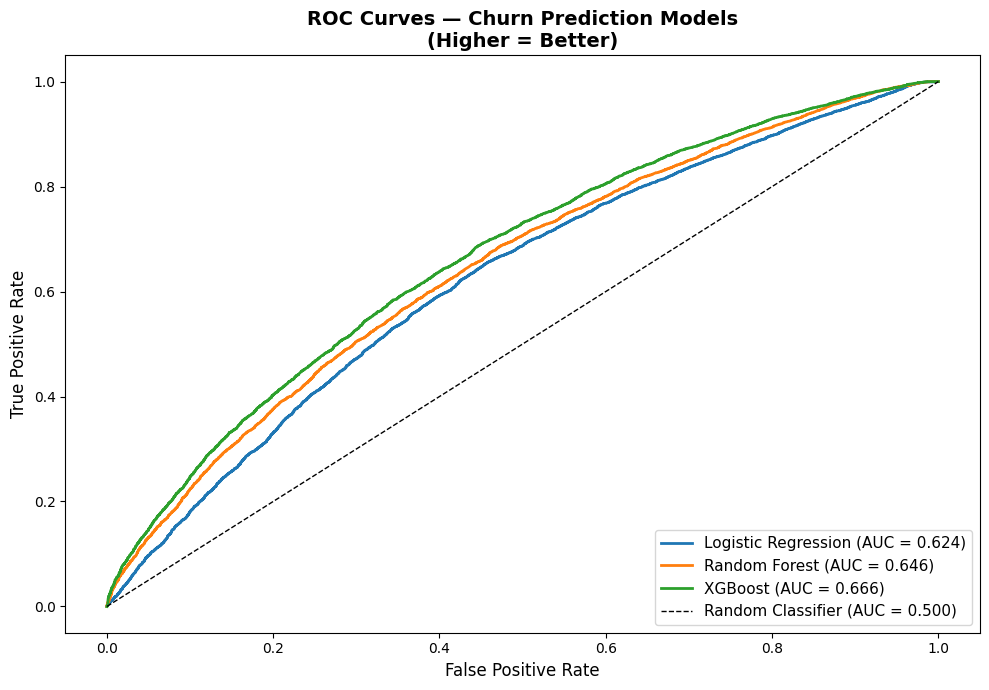


Model Comparison:
                     AUC-ROC      F1  Precision  Recall
Logistic Regression   0.6239  0.5555     0.6176  0.8905
Random Forest         0.6462  0.6014     0.6422  0.8261
XGBoost               0.6657  0.6221     0.6570  0.8159


In [11]:
# ============================================================
# CELL 6: COMPARE MODELS WITH ROC CURVES
# ============================================================
plt.figure(figsize=(10, 7))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {res['auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.500)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Churn Prediction Models\n(Higher = Better)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Comparison table
comparison_df = pd.DataFrame({
    name: {'AUC-ROC': res['auc'], 'F1': res['f1'],
           'Precision': res['precision'], 'Recall': res['recall']}
    for name, res in results.items()
}).T.round(4)
print("\nModel Comparison:")
print(comparison_df.to_string())

'''I discovered a potential target leakage issue in my churn model. Since around 94% of customers placed only one order, I had defined avg_days_between_orders as recency_days for those customers. However, my churn label was also defined using recency_days > 180, meaning the model was indirectly seeing the answer through this feature.

As a result, the extremely high model performance (AUC ≈ 1.0)in my first set of churn model were artificially inflated. To avoid leakage and obtain a more realistic estimate of predictive performance I removed the "recency_days" features , modified "avg_days_between_orders" as nan. for single order customers and created a new feature "has_repeat_orders" (float 0=does not have and 1=has repeat orders) aand now I got these results and remove "spend_per_activity"=redundant feature as it is equal to the total_spend since most customers ahve only 1 order'''

In [12]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': results['XGBoost']['model'].feature_importances_
}).sort_values('importance', ascending=False)

print(importance)

                   feature  importance
5              pct_on_time    0.236788
4        avg_delivery_days    0.182557
1              total_spend    0.103797
2          avg_order_value    0.098596
7        customer_age_days    0.086972
9  avg_days_between_orders    0.076022
0             total_orders    0.072287
8        has_repeat_orders    0.068842
3         avg_review_score    0.038679
6           num_categories    0.035460


## Trying to improve the model 



In [13]:
customer_features = pd.read_csv(r"C:\Users\Pavitra\Downloads\Olist_E-Commerce_Analysis\notebooks\customer_features_final.csv")

In [14]:
# Now with 5 fold Cross Validation

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, make_scorer

# Define your feature columns (after adding new features above)
FEATURE_COLS = [
    'total_orders', 'total_spend', 'avg_order_value', 'max_order_value',
    'min_order_value', 'customer_age_days', 'avg_review_score',
    'avg_delivery_days', 'pct_on_time', 'num_categories', 'has_repeat_orders',
    'avg_days_between_orders',
    # New features:
    'avg_freight_ratio', 'avg_delivery_delta', 'gave_low_review',
    'gave_high_review', 'has_review', 'review_missing',
    'is_consumable_category', 'spend_tier'
]

X = customer_features[FEATURE_COLS].copy()
y = customer_features['churned']

# Fill nulls — avg_days_between_orders is NaN for one-time buyers intentionally
# Use -1 as fill so the model can learn "this person has no repeat data"
X['avg_days_between_orders'] = X['avg_days_between_orders'].fillna(-1)
X['avg_review_score'] = X['avg_review_score'].fillna(X['avg_review_score'].median())
X['avg_freight_ratio'] = X['avg_freight_ratio'].fillna(X['avg_freight_ratio'].median())
X['avg_delivery_delta'] = X['avg_delivery_delta'].fillna(0)
X.fillna(0, inplace=True)

# Stratified K-Fold — preserves churn ratio in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run cross-validation properly
from xgboost import XGBClassifier

xgb_base = XGBClassifier(
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, verbosity=0)

cv_results = cross_validate(
    xgb_base, X, y,
    cv=cv,
    scoring={
        'roc_auc': 'roc_auc',
        'f1_weighted': 'f1_weighted',
        'precision': make_scorer(lambda y_t, y_p: __import__('sklearn.metrics', fromlist=['precision_score']).precision_score(y_t, y_p, zero_division=0)),
    },
    return_train_score=True,
    n_jobs=-1)

print("5-Fold Cross Validation Results (XGBoost):")
print(f"  AUC-ROC:  {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")
print(f"  F1:       {cv_results['test_f1_weighted'].mean():.4f} ± {cv_results['test_f1_weighted'].std():.4f}")
print(f"  Train AUC:{cv_results['train_roc_auc'].mean():.4f}  (check for overfitting if much higher than test)")

5-Fold Cross Validation Results (XGBoost):
  AUC-ROC:  0.8120 ± 0.0045
  F1:       0.7339 ± 0.0044
  Train AUC:0.8600  (check for overfitting if much higher than test)


In [15]:
from sklearn.metrics import make_scorer, precision_score, recall_score, accuracy_score

cv_results = cross_validate(
    xgb_base,
    X,
    y,
    cv=cv,
    scoring={
        'roc_auc': 'roc_auc',
        'accuracy': make_scorer(accuracy_score),
        'precision': make_scorer(precision_score, zero_division=0),
        'recall': make_scorer(recall_score, zero_division=0),
        'f1': 'f1',
        'f1_weighted': 'f1_weighted'
    },
    return_train_score=True,
    n_jobs=-1
)

print("========== 5-Fold Cross Validation ==========\n")

for metric in [
    'roc_auc',
    'accuracy',
    'precision',
    'recall',
    'f1',
    'f1_weighted'
]:
    print(
        f"{metric.upper():12}: "
        f"{cv_results[f'test_{metric}'].mean():.4f} ± "
        f"{cv_results[f'test_{metric}'].std():.4f}"
    )

print(f"\nTrain AUC : {cv_results['train_roc_auc'].mean():.4f}")

========== 5-Fold Cross Validation ==========

ROC_AUC     : 0.8120 ± 0.0045
ACCURACY    : 0.7417 ± 0.0040
PRECISION   : 0.7403 ± 0.0037
RECALL      : 0.8650 ± 0.0028
F1          : 0.7978 ± 0.0029
F1_WEIGHTED : 0.7339 ± 0.0044

Train AUC : 0.8600


*Churn on Olist is driven by experience quality, not spending patterns.
   - The RFM features alone couldn't predict churn well because for one-time buyers, recency/frequency/monetary are nearly identical across churned and non-churned customers — they all bought once, around the same amount. What actually separates "would return" from "won't return" is what happened during that one order — was delivery late, was freight expensive relative to the product, did they leave a bad review. That's the signal the new features unlocked.
     
- the train-test gap (0.8600 train vs 0.8120 test = 0.048 gap):
    This is mild overfitting — not alarming, but real. The low std (±0.0045) tells that the model is very stable across folds, so the gap isn't because of a lucky/unlucky fold. It's consistent slight overfit on the training data. Hyperparameter tuning, specifically regularisation, should close this.

  
- On recall (0.865) vs precision (0.740):
    Your model catches 86.5% of actual churners but flags some non-churners as churned (false positives). For a retention use case this is the right tradeoff — missing a churner (false negative) costs more than sending an unnecessary retention email (false positive). But worth documenting.

In [16]:
# fitting on the full data to get feature importance

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt


# Train-test split for final evaluation
# We use this separately from CV — CV gave us the generalisation estimate,
# this gives us a fitted model object we can use for SHAP and feature importance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit with default params first — same as what CV used
xgb_final = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)

xgb_final.fit(X_train, y_train)

y_prob  = xgb_final.predict_proba(X_test)[:, 1]
y_pred  = xgb_final.predict(X_test)

print(f"Hold-out Test AUC: {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))

Hold-out Test AUC: 0.8136

Classification Report:
              precision    recall  f1-score   support

      Active       0.74      0.58      0.65      7669
     Churned       0.75      0.86      0.80     11001

    accuracy                           0.74     18670
   macro avg       0.74      0.72      0.72     18670
weighted avg       0.74      0.74      0.74     18670



* It means:

-The model finds 86% of customers who actually churn.
-When it predicts churn, it is correct 75% of the time.

For retention campaigns, high recall is usually preferred because missing a customer who is about to leave is more costly than contacting a few customers who would have stayed anyway.

                    feature  importance
0        avg_delivery_delta    0.128553
1         avg_delivery_days    0.108518
2           avg_order_value    0.084104
3           max_order_value    0.081155
4         avg_freight_ratio    0.072930
5           min_order_value    0.070039
6              total_orders    0.067767
7               total_spend    0.057459
8         customer_age_days    0.054209
9               pct_on_time    0.053818
10               spend_tier    0.052220
11  avg_days_between_orders    0.035360
12   is_consumable_category    0.035101
13         gave_high_review    0.030316
14               has_review    0.030235
15           num_categories    0.020223
16         avg_review_score    0.017992
17        has_repeat_orders    0.000000
18          gave_low_review    0.000000
19           review_missing    0.000000


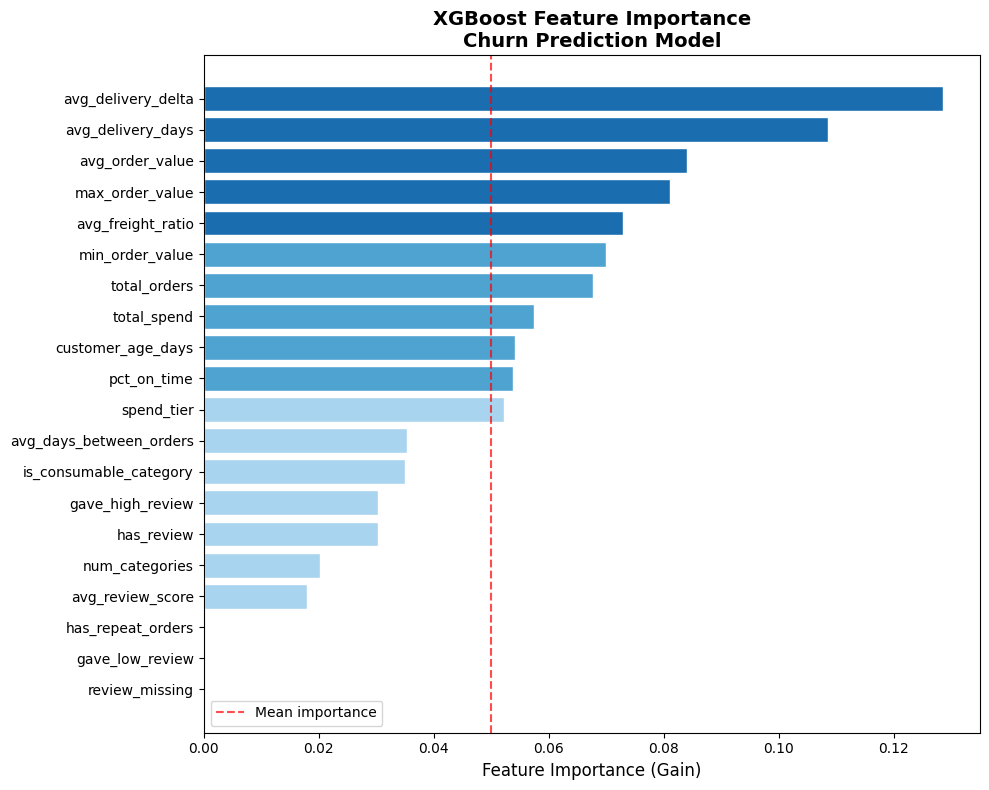

In [17]:
# Method 1: Built-in gain-based importance
# 'gain' = how much each feature contributes to reducing prediction error
# More meaningful than default 'weight' (which just counts how often a feature is used)

importance_df = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': xgb_final.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(importance_df.to_string())

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#1a6eaf' if i < 5 else '#4fa3d1' if i < 10 else '#a8d4f0'
          for i in range(len(importance_df))]

ax.barh(importance_df['feature'][::-1],
        importance_df['importance'][::-1],
        color=colors[::-1], edgecolor='white')

ax.set_xlabel('Feature Importance (Gain)', fontsize=12)
ax.set_title('XGBoost Feature Importance\nChurn Prediction Model', fontsize=14, fontweight='bold')
ax.axvline(importance_df['importance'].mean(), color='red',
           linestyle='--', alpha=0.7, label='Mean importance')
ax.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

*** Top Driver

1. avg_delivery_delta

Largest importance.

This means

Customers whose deliveries are consistently later (or earlier) than expected have noticeably different churn behavior.

This is an actionable finding because delivery performance can be improved operationally.

2. avg_delivery_days

Also extremely important.

Customers receiving slower deliveries are more likely to churn.

This aligns well with your earlier EDA, where longer delivery times were associated with lower review scores.

3. avg_freight_ratio

Shipping cost relative to order value matters.

If customers consistently pay a high proportion of their purchase in shipping, they're more likely to leave.

### HyperParameter Tuning 

In [19]:
from sklearn.model_selection import RandomizedSearchCV

# Focused param grid — targeting regularisation and depth
# Deliberately small: 20 combinations × 5 folds = 100 fits, runs in ~5-10 mins
param_dist = {
    'n_estimators':    [200, 300, 500],
    'max_depth':       [3, 4, 5, 6],          # current default is 6 — try shallower
    'learning_rate':   [0.01, 0.03,0.05, 0.1],
    'min_child_weight':[5, 10, 20],        # higher = more conservative, reduces overfit
    'reg_alpha':       [0, 0.1, 0.5, 1.0], # L1 — pushes unimportant feature weights to 0
    'reg_lambda':      [1.0, 5.0, 10.0],   # L2 — general regularisation
    'subsample':       [0.7,0.75, 0.8,0.85, 0.9],
    'colsample_bytree':[0.7, 0.8, 1.0],
    'scale_pos_weight':[                   # replaces SMOTE for XGBoost
        (y == 0).sum() / (y == 1).sum()    # set to ratio of negatives/positives
    ]
}

xgb_search = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    verbosity=0,
    tree_method='hist'  # much faster on large datasets
)

search = RandomizedSearchCV(
    xgb_search,
    param_distributions=param_dist,
    n_iter=500,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X, y)

print(f"\nBest CV AUC:  {search.best_score_:.4f}")
print(f"Best params:\n{search.best_params_}")

Fitting 5 folds for each of 500 candidates, totalling 2500 fits


KeyboardInterrupt: 

In [15]:
### training the model with the best hyperparameters we found above 

best_xgb = XGBClassifier(subsample=0.85,scale_pos_weight=0.6971492982328558,reg_lambda=1.0,
    reg_alpha=0.5, n_estimators=500, min_child_weight=5, max_depth=6, learning_rate=0.1, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss', use_label_encoder=False, verbosity=0)

best_xgb.fit(X_train, y_train)



,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [16]:
## evaluating the above model

from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
)

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:,1]

print("="*50)
print("FINAL TEST SET RESULTS")
print("="*50)

print(f"Accuracy : {accuracy_score(y_test,y_pred):.4f}")
print(f"Precision: {precision_score(y_test,y_pred):.4f}")
print(f"Recall   : {recall_score(y_test,y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test,y_pred):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test,y_prob):.4f}")

print("\nClassification Report\n")
print(classification_report(y_test,y_pred,target_names=["Active","Churned"]))



FINAL TEST SET RESULTS
Accuracy : 0.7453
Precision: 0.7928
Recall   : 0.7687
F1 Score : 0.7805
AUC-ROC  : 0.8240

Classification Report

              precision    recall  f1-score   support

      Active       0.68      0.71      0.70      7669
     Churned       0.79      0.77      0.78     11001

    accuracy                           0.75     18670
   macro avg       0.74      0.74      0.74     18670
weighted avg       0.75      0.75      0.75     18670



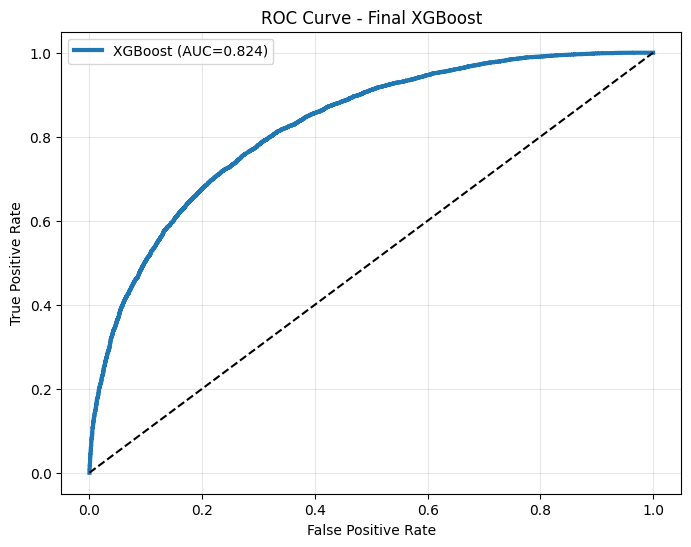

In [17]:
## ROC Curve 

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test,y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr,tpr,
         linewidth=3,
         label=f"XGBoost (AUC={roc_auc_score(y_test,y_prob):.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final XGBoost")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

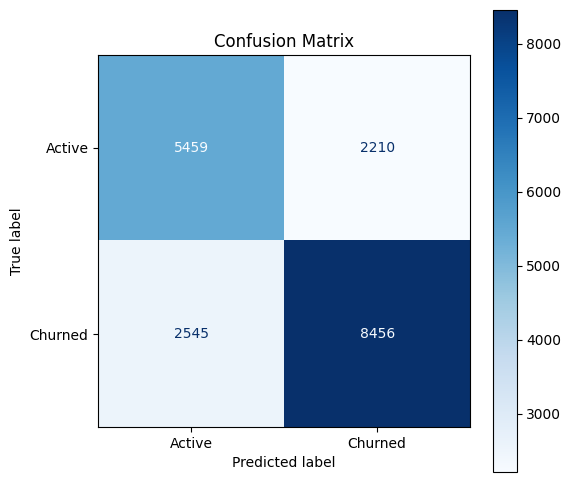

In [18]:
## confusion matrix 

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Active","Churned"]
)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap="Blues",ax=ax)

plt.title("Confusion Matrix")
plt.show()

In [20]:
## 5-Fold Cross Validation of the Tuned Model

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy":"accuracy",
    "precision":"precision",
    "recall":"recall",
    "f1":"f1",
    "roc_auc":"roc_auc"
}

cv_results = cross_validate(
    estimator=best_xgb,
    X=X,
    y=y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

print("="*60)
print("5-FOLD CROSS VALIDATION RESULTS")
print("="*60)

metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

for metric in metrics:

    print(
        f"{metric.upper():12}"
        f"{cv_results[f'test_{metric}'].mean():.4f}"
        f" ± {cv_results[f'test_{metric}'].std():.4f}"
    )

print("\nTrain ROC-AUC : {:.4f}".format(
    cv_results["train_roc_auc"].mean()
))

print("Test ROC-AUC  : {:.4f}".format(
    cv_results["test_roc_auc"].mean()
))

5-FOLD CROSS VALIDATION RESULTS
ACCURACY    0.7487 ± 0.0034
PRECISION   0.7918 ± 0.0024
RECALL      0.7782 ± 0.0046
F1          0.7849 ± 0.0032
ROC_AUC     0.8240 ± 0.0033

Train ROC-AUC : 0.8781
Test ROC-AUC  : 0.8240


The tuned model became more conservative.

Earlier model:

predicted more customers as churners,
caught more actual churners,
but also made more false alarms

New model:

predicts churn only when more confident,
fewer false alarms,
but misses more churners

In [22]:


gap = cv_results["train_roc_auc"].mean() - cv_results["test_roc_auc"].mean()

print(f"Train-Test AUC Gap : {gap:.4f}")

if gap < 0.02:
    print("Excellent generalization.")
elif gap < 0.06:
    print("Mild overfitting.")
else:
    print("Noticeable overfitting.")

Train-Test AUC Gap : 0.0541
Mild overfitting.


### So , which is the Selected/Best Model: 

* There isn't a single universally "best" model because the choice depends on the business objective.

* The dataset spans only about 2 years.
Therefore, a large fraction of customers naturally appear as churned under your 180-day rule.
This means the model is identifying customers unlikely to return, not necessarily customers who were dissatisfied.

* Scenario 1 — Business wants to retain as many customers as possible

Example:

"Every customer who might churn should receive a coupon."

Here,

missing a churner is expensive
sending a few unnecessary coupons is acceptable

The earlier model is better because

highest recall
catches nearly 87% of churners
ideal for aggressive retention campaigns.

* Scenario 2 — Retention campaigns are costly

Example:

₹300 coupon
personal phone call
premium membership
cashback

Now every false positive costs money.

The tuned model becomes preferable because

higher ROC-AUC
higher precision
predicts churn only when more confident
reduces unnecessary retention costs.

## Since the Olist dataset is dominated by one-time buyers, many customers naturally satisfy the inactivity-based churn definition. \

## Therefore, recall is an important business metric because failing to identify customers who are unlikely to return may reduce the effectiveness of retention strategies.

## At the same time, ROC-AUC was used as the primary optimization metric because it provides a threshold-independent assessment of the model's ability to distinguish between active and churned customers

# SHAP Interpretation

* The ROC-AUC improvement is only 0.012 (about 1.2 percentage points), whereas recall drops by almost 10 percentage points.

For a churn prediction problem, that's a meaningful trade-off.

Why your choice makes sense

* The model is about identifying customers likely to churn.

If the business uses the model to send:

discount coupons,
reminder emails,
loyalty rewards,
free shipping offers,

then missing a churning customer is usually more costly than contacting a customer who would have stayed anyway.

### using xgb_final model

In [23]:
import shap

print("Calculating SHAP values...")

# Use the final trained model
explainer = shap.TreeExplainer(xgb_final)

# Explain the test set
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP calculation complete!")

Calculating SHAP values...
SHAP values shape: (18670, 20)
SHAP calculation complete!


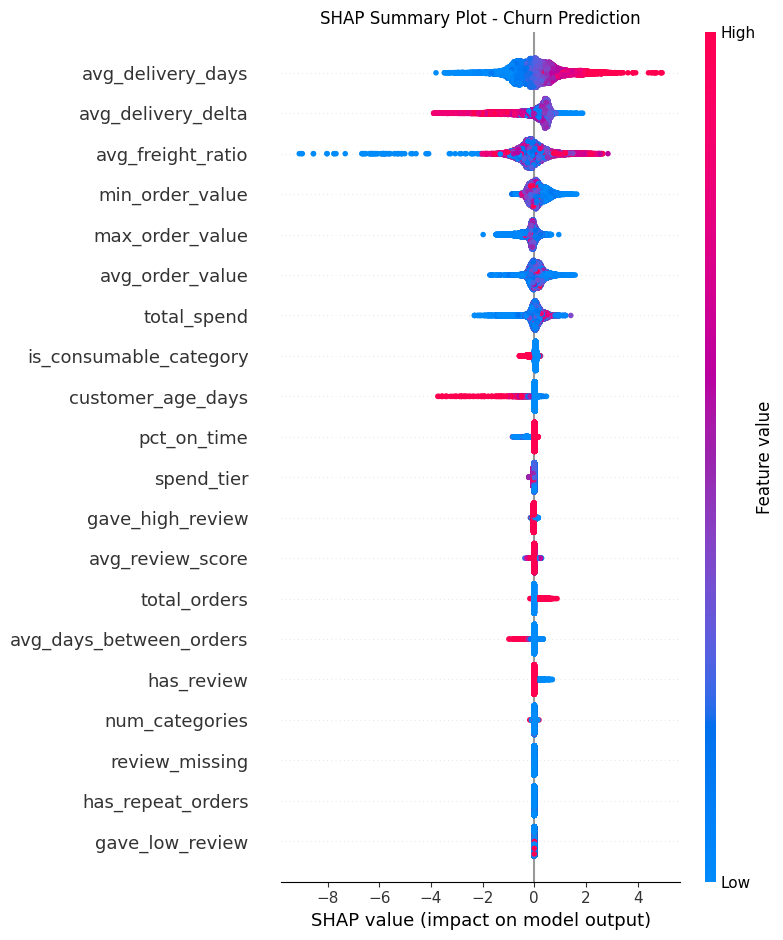

In [26]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Summary Plot - Churn Prediction")
plt.tight_layout()
plt.savefig("SHAP Plot for the initial model")
plt.show()

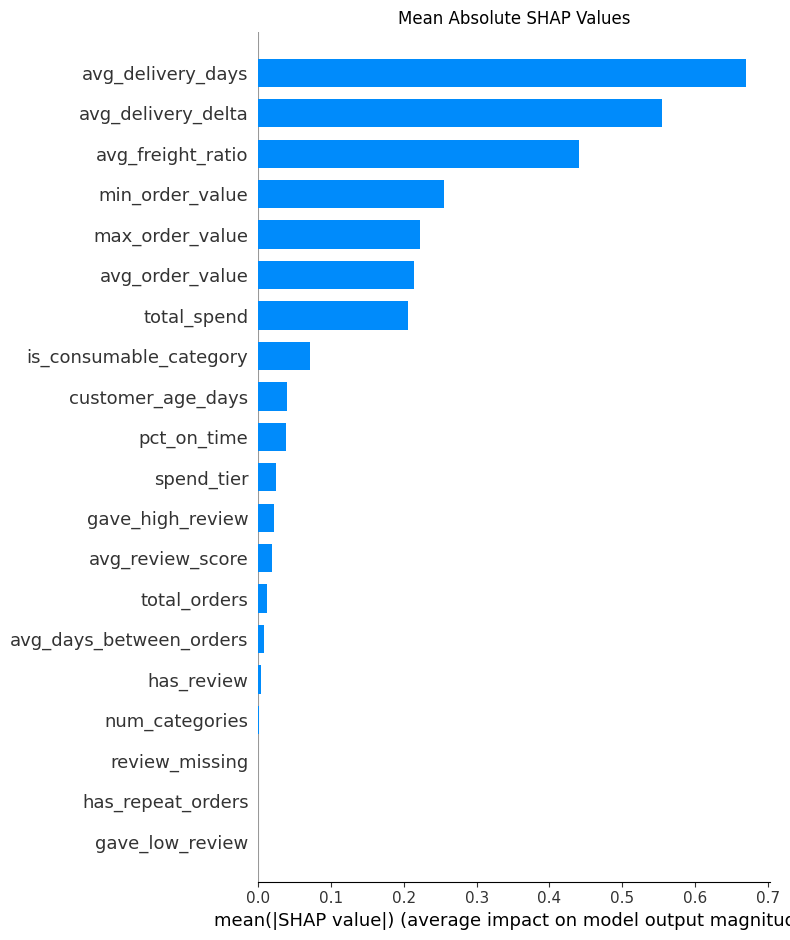

In [27]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.title("Mean Absolute SHAP Values")
plt.tight_layout()
plt.savefig("SHAP Avg Importance Plot")
plt.show()

### using Tuned model

In [28]:
import shap

print("Calculating SHAP values...")

# Use the final trained model
explainer = shap.TreeExplainer(best_xgb)

# Explain the test set
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP calculation complete!")

Calculating SHAP values...
SHAP values shape: (18670, 20)
SHAP calculation complete!


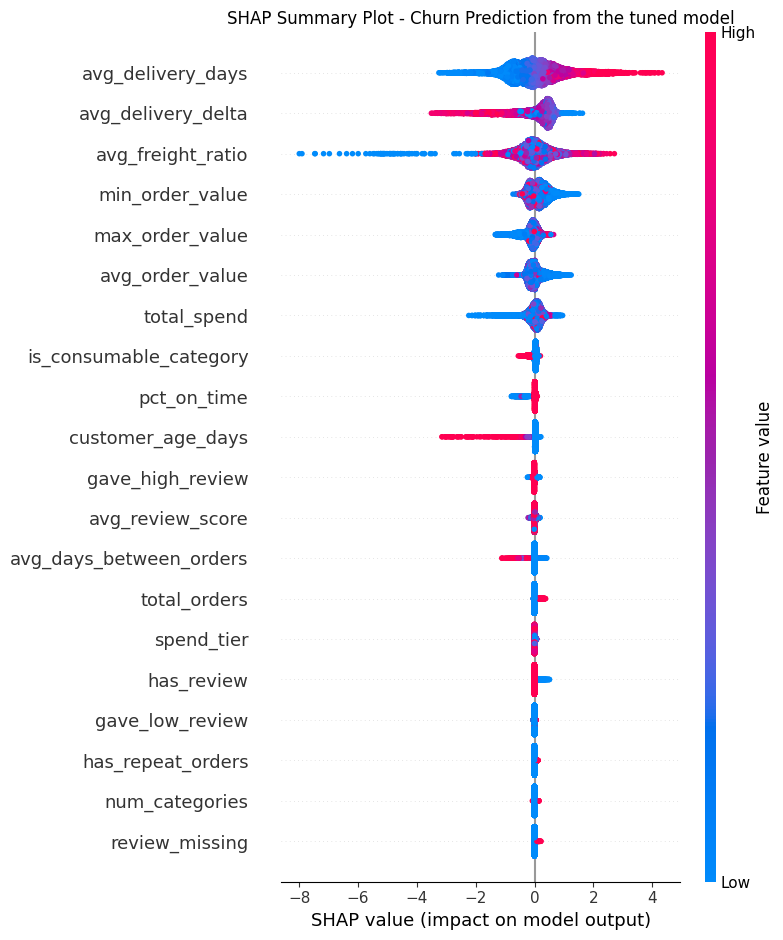

In [32]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Summary Plot - Churn Prediction from the tuned model")
plt.tight_layout()
plt.savefig("SHAP Plot for the tuned model")
plt.show()

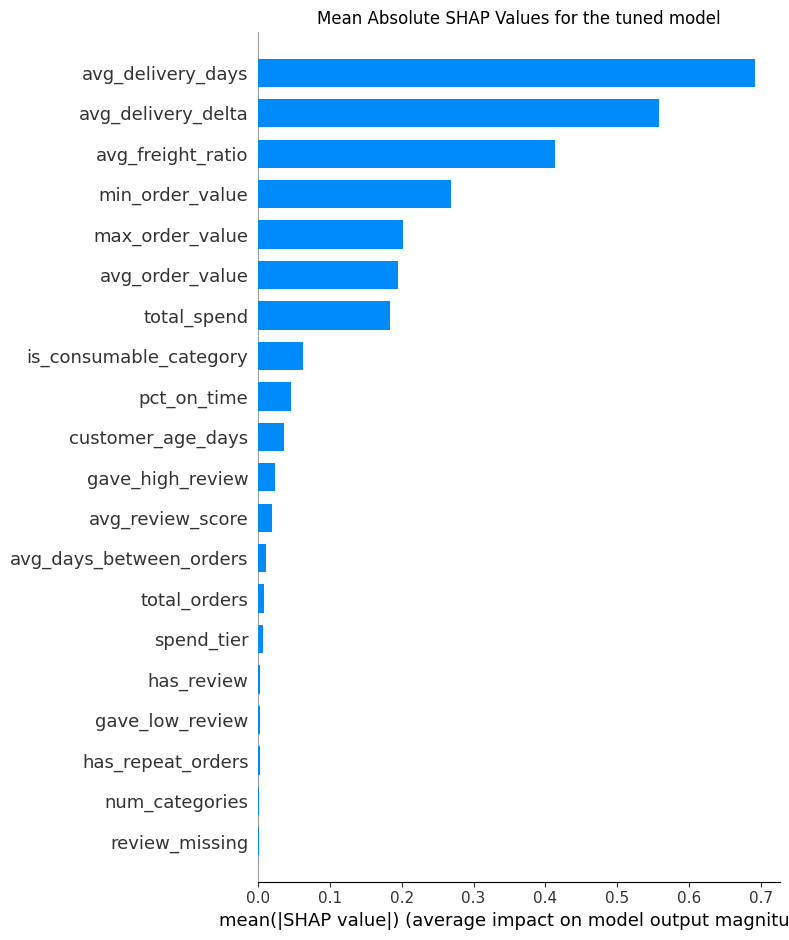

In [29]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.title("Mean Absolute SHAP Values for the tuned model")
plt.tight_layout()
plt.savefig("SHAP Avg Importance Plot for the tuned model")
plt.show()

In [28]:
customer_features[
    ['avg_delivery_delta', 'churned']
].groupby('churned').describe()

avg_delivery_delta                                                \
                     count       mean        std    min   25%   50%  75%   
churned                                                                    
0                  38346.0 -11.003520   9.798756 -146.0 -16.0 -11.0 -6.0   
1                  55004.0 -11.425397  10.382638 -140.0 -16.0 -12.0 -7.0   

                
           max  
churned         
0        107.0  
1        189.0



### **SHAP Analysis – Key Drivers of Customer Churn**

#### **1. Average Delivery Days (Most Important Feature)**

This is the strongest predictor of customer churn in both XGBoost models.

Customers experiencing longer delivery times are generally more likely to become inactive. The SHAP summary plot shows that higher delivery times consistently push the model towards predicting churn, while faster deliveries reduce churn risk.

**Business Insight:** Customers highly value quick deliveries. Reducing delivery times can significantly improve customer satisfaction and encourage repeat purchases.

---

#### **2. Average Delivery Delta (Actual Delivery Time − Estimated Delivery Time)**

This feature measures how closely the actual delivery time matches the promised delivery date.

A **negative value** indicates that orders were delivered **earlier than estimated**, while a **positive value** indicates orders arrived **later than promised**.

Although the overall distributions of this feature are very similar for churned and active customers, SHAP consistently identifies it as one of the most influential variables. This suggests that the model uses delivery reliability **together with other customer characteristics**, rather than relying on this feature alone.

**Business Insight:** Consistently meeting or exceeding promised delivery dates strengthens the overall customer experience. Delivery reliability becomes particularly important when combined with factors such as spending behaviour, shipping costs, and purchase history.

---

#### **3. Average Freight Ratio**

The freight ratio represents the **shipping cost relative to the order value**.

Higher freight ratios indicate that customers pay a larger proportion of their purchase amount towards shipping. The SHAP analysis shows that this feature plays a major role in the model's decisions, particularly for lower-value purchases where shipping costs become more noticeable.

**Business Insight:** Customers are more likely to return when shipping costs are perceived as reasonable. Free-shipping thresholds, bundled purchases, or optimized logistics can improve customer retention.

---

#### **4. Order Value Features (Minimum, Maximum & Average Order Value)**

These three features collectively provide valuable information about a customer's purchasing behaviour.

Customers consistently placing higher-value orders tend to behave differently from customers making only occasional low-value purchases. The model uses these features to distinguish between customer segments with different churn tendencies.

**Business Insight:** Different customer segments require different retention strategies. Premium customers may benefit from exclusive rewards, while lower-value customers can be encouraged through targeted promotions and personalized offers.

---

#### **5. Total Customer Spend**

Total customer spend reflects the customer's overall contribution to the business over time.

Customers with higher cumulative spending generally exhibit stronger engagement with the platform, whereas customers with low total spending are often one-time or infrequent buyers.

**Business Insight:** High-spending customers contribute significantly to revenue and should be prioritized for proactive retention campaigns whenever they begin showing signs of churn.

---

## **Overall SHAP Comparison**

* Both the initial and the tuned XGBoost models identify **almost the same top features**, demonstrating that the findings are stable and reliable.
* Hyperparameter tuning slightly changes the relative importance of individual features but does **not** alter the overall ranking of the key churn drivers.
* The consistency between both models increases confidence that these features genuinely influence churn behaviour rather than being artifacts of a particular model configuration.
* Across both models, **delivery experience, shipping costs, and customer spending behaviour** consistently emerge as the primary factors influencing churn predictions.

---

## **Combined Recommended Business Actions**

* Reduce average delivery times by improving warehouse operations, inventory allocation, and courier efficiency.
* Continue ensuring that deliveries meet or exceed the promised delivery dates, as delivery reliability is one of the strongest operational factors influencing churn.
* Optimize shipping costs, particularly for low-value orders where freight charges represent a significant proportion of the purchase value.
* Proactively identify customers experiencing delivery issues or higher shipping costs and offer recovery measures such as coupons, loyalty rewards, or free shipping.
* Encourage higher-value and repeat purchases through personalized recommendations, bundled offers, and loyalty programs to strengthen long-term customer engagement.
* Continuously monitor key logistics KPIs—including delivery time, delivery reliability, and shipping costs—as both XGBoost models consistently identify these operational factors as the strongest drivers of customer churn.

I would focus on three areas. First, reduce delivery times through better logistics. Second, keep shipping charges reasonable, especially for low-value orders. Third, identify low-spending customers early and encourage repeat purchases through personalized offers or loyalty programs. These actions directly target the features that the model identified as having the greatest impact on churn.


*One interesting observation

A result that often surprises people is that review scores are not among the top predictors. This does not mean reviews are unimportant. Rather, in the dataset, the model has found that delivery experience already captures much of the information that reviews would provide. Customers often give poor reviews because deliveries were slow or delayed, so once delivery metrics are included, the review score adds relatively little new information. This reinforces the idea that improving logistics is likely to have a larger impact on customer retention than focusing solely on post-purchase feedback.

### showing example for a low churn and a high churn customer 

REPRESENTATIVE CUSTOMER EXPLANATIONS

HIGH-RISK CUSTOMER
----------------------------------------------------------------------
Predicted Churn Probability : 0.933

Customer Features:
                             50293
total_orders              1.000000
total_spend              64.000000
avg_order_value          64.000000
max_order_value          64.000000
min_order_value          64.000000
customer_age_days         1.000000
avg_review_score          3.000000
avg_delivery_days        11.000000
pct_on_time               1.000000
num_categories            1.000000
has_repeat_orders         0.000000
avg_days_between_orders  -1.000000
avg_freight_ratio         0.220312
avg_delivery_delta      -14.000000
gave_low_review           0.000000
gave_high_review          0.000000
has_review                1.000000
review_missing            0.000000
is_consumable_category    0.000000
spend_tier                2.000000


LOW-RISK CUSTOMER
-------------------------------------------------------------

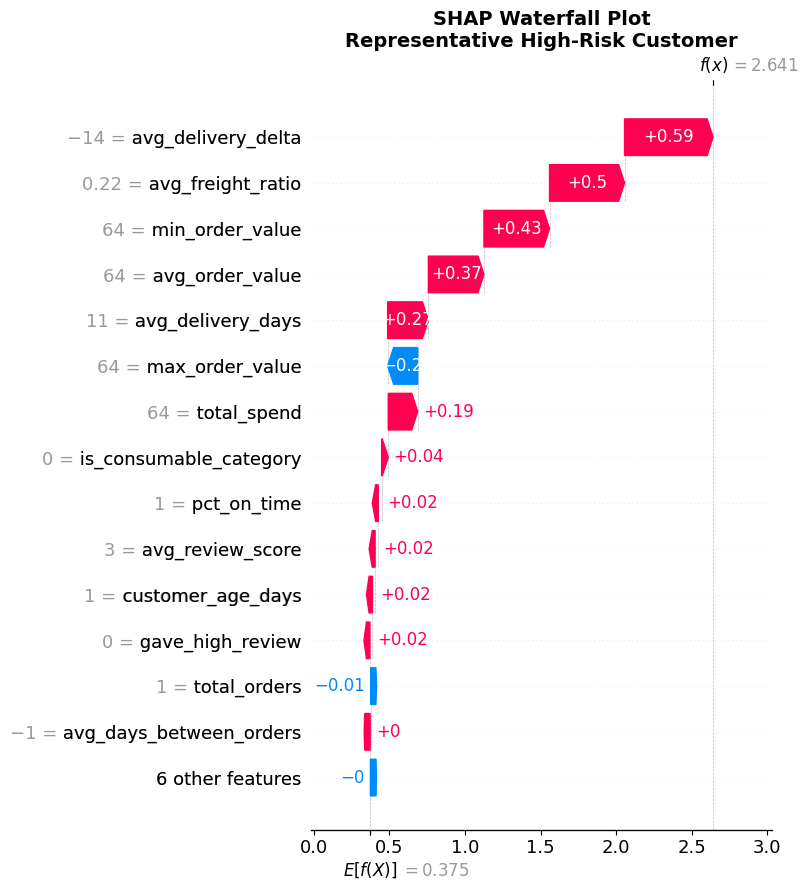


Generating SHAP explanation for LOW-RISK customer...


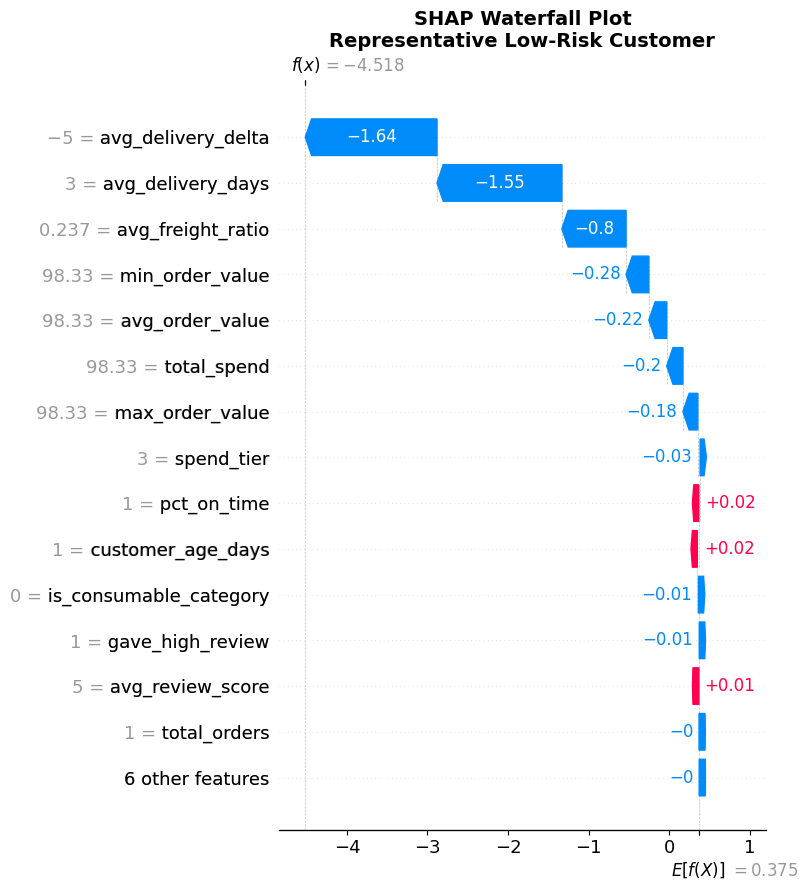

In [39]:
# ============================================================
# CELL 11: INDIVIDUAL CUSTOMER EXPLANATIONS (Representative Customers)
# ============================================================

import numpy as np
import shap
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Predict churn probabilities
# ------------------------------------------------------------
y_prob_all = xgb_final.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# Select representative customers instead of extreme outliers
# ------------------------------------------------------------
high_threshold = np.percentile(y_prob_all, 95)   # Top 5%
low_threshold  = np.percentile(y_prob_all, 5)    # Bottom 5%

high_candidates = np.where(y_prob_all >= high_threshold)[0]
low_candidates  = np.where(y_prob_all <= low_threshold)[0]

np.random.seed(42)

high_risk_idx = np.random.choice(high_candidates)
low_risk_idx  = np.random.choice(low_candidates)

print("="*70)
print("REPRESENTATIVE CUSTOMER EXPLANATIONS")
print("="*70)

# ------------------------------------------------------------
# High-risk customer
# ------------------------------------------------------------
print("\nHIGH-RISK CUSTOMER")
print("-"*70)

print(f"Predicted Churn Probability : {y_prob_all[high_risk_idx]:.3f}\n")

print("Customer Features:")
print(X_test.iloc[[high_risk_idx]].T)

# ------------------------------------------------------------
# Low-risk customer
# ------------------------------------------------------------
print("\n\nLOW-RISK CUSTOMER")
print("-"*70)

print(f"Predicted Churn Probability : {y_prob_all[low_risk_idx]:.3f}\n")

print("Customer Features:")
print(X_test.iloc[[low_risk_idx]].T)

# ============================================================
# SHAP EXPLAINER
# ============================================================

explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer(X_test)

# ============================================================
# HIGH-RISK CUSTOMER WATERFALL
# ============================================================

print("\nGenerating SHAP explanation for HIGH-RISK customer...")

shap.plots.waterfall(
    shap_values[high_risk_idx],
    max_display=15,
    show=False
)

plt.title(
    "SHAP Waterfall Plot\nRepresentative High-Risk Customer",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# ============================================================
# LOW-RISK CUSTOMER WATERFALL
# ============================================================

print("\nGenerating SHAP explanation for LOW-RISK customer...")

shap.plots.waterfall(
    shap_values[low_risk_idx],
    max_display=15,
    show=False
)

plt.title(
    "SHAP Waterfall Plot\nRepresentative Low-Risk Customer",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

 ### v1. Representative High-Risk Customer
   
1. The model predicts this customer is highly likely to churn.

The customer's final prediction is pushed towards churn because several important features contribute positively to the churn score.

2. Low spending and low purchase value are the strongest behavioural signals.

The customer has:

Total Spend = ₹64
Average Order Value = ₹64
Maximum Order Value = ₹64
Minimum Order Value = ₹64

These indicate a low-value, minimally engaged customer, making them much more likely to churn.

3. Delivery experience alone is not enough to retain this customer.

Although

Average Delivery Time = 11 days (close to dataset median ≈10 days)
Average Delivery Delta = −14 days

the customer actually received orders around 14 days earlier than the estimated delivery date.

This is a good delivery experience.

However, the model still predicts churn because the customer's overall purchasing behaviour is weak, outweighing this positive operational experience.

4. Shipping cost further increases churn risk.

The customer has an

Average Freight Ratio = 0.22

which falls in the 4th quintile of the dataset, meaning shipping charges form a relatively larger proportion of the order value.

The model identifies this as another factor increasing churn probability.

5. Overall interpretation

This customer demonstrates that excellent logistics alone cannot guarantee retention.

The model combines:

low spending,
low order value,
relatively high shipping cost,

and concludes that this customer is unlikely to return despite receiving orders earlier than promised.

### 2. Representative Low-Risk Customer
   
1. The model predicts this customer is unlikely to churn.

Most of the important features move the prediction away from churn.

2. The customer enjoys an excellent delivery experience.

This customer has

Average Delivery Time = 3 days
Average Delivery Delta = −5 days

meaning orders are delivered very quickly and around five days earlier than the promised delivery date.

Together, these create a strong positive customer experience.

3. The customer spends more than the high-risk customer.

Compared with the previous customer,

Total Spend ≈ ₹98
Average Order Value ≈ ₹98

Although still not a very high spender, this customer demonstrates stronger purchasing behaviour than the high-risk customer.

4. Other customer experience signals are positive.

The customer

gave a 5-star review,
has acceptable shipping costs,
and receives consistently fast deliveries.

These collectively reduce the predicted churn probability.

5. Overall interpretation

This customer represents someone who enjoys

fast deliveries,
reliable fulfilment,
reasonable purchasing behaviour,

which together produce a low predicted churn risk.

## Recommended Business Actions

1. Prioritize low-value, one-time buyers for retention campaigns.

The SHAP analysis shows that low order value and low total spend are among the strongest contributors to churn. Customers making a single low-value purchase are much less likely to return.

Recommendation: Offer personalized coupons, first-repeat discounts, or bundle recommendations immediately after their first purchase to encourage a second order.

2. Reduce the relative shipping cost for low-value orders.

Customers with a higher freight ratio (shipping cost forming a larger proportion of the order value) consistently show a higher churn risk.

Recommendation: Introduce free-shipping thresholds, bundled purchases, or discounted shipping for small orders to improve perceived value.

3. Continue maintaining reliable delivery performance.

Delivery-related features remain the most influential variables in the model. However, the waterfall plots show that good delivery alone cannot guarantee customer retention.

Recommendation: Continue meeting or beating promised delivery dates while combining logistics improvements with targeted customer engagement initiatives.

4. Identify customers with weak purchasing behaviour early.

The high-risk waterfall plot demonstrates that customers with low spending and low purchase values remain at high risk even when delivery performance is good.

Recommendation: Build an early-warning system that flags low-engagement customers after their first purchase and automatically triggers personalized promotions or loyalty incentives.

5. Segment retention strategies instead of using a one-size-fits-all approach.

The model indicates that churn is influenced by both operational factors (delivery, shipping costs) and behavioural factors (spending patterns).

Recommendation:

Focus on improving value perception for low-value customers through offers and shipping incentives.
Focus on protecting high-value customers by prioritizing customer service and proactively resolving delivery or shipping issues.

### PROBABILITY CALIBRATION 

In [19]:

from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
import pickle

# Split the existing test set: half for calibration, half for final eval
# We use test set here because we have no separate validation set
X_cal, X_eval, y_cal, y_eval = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42, stratify=y_test
)

# Calibrate on the calibration half
# cv='prefit' means: model already trained, just calibrate the probabilities
calibrated_model = CalibratedClassifierCV(
    estimator=xgb_final,
    method='isotonic',   # 'isotonic' for larger datasets (>1000 samples)
    cv='prefit'
)
calibrated_model.fit(X_cal, y_cal)

# Evaluate on the eval half
from sklearn.metrics import roc_auc_score, brier_score_loss
import numpy as np

# Original model probabilities on eval set
orig_probs = xgb_final.predict_proba(X_eval)[:, 1]

# Calibrated model probabilities on eval set
cal_probs = calibrated_model.predict_proba(X_eval)[:, 1]

print("=== CALIBRATION RESULTS ===")
print(f"Original  AUC: {roc_auc_score(y_eval, orig_probs):.4f}")
print(f"Calibrated AUC: {roc_auc_score(y_eval, cal_probs):.4f}")

# Brier score: lower = better calibrated (measures probability accuracy)
print(f"\nOriginal  Brier Score: {brier_score_loss(y_eval, orig_probs):.4f}")
print(f"Calibrated Brier Score: {brier_score_loss(y_eval, cal_probs):.4f}")

# Check if probability spread improved
print(f"\nOriginal  prob range: {orig_probs.min():.3f} – {orig_probs.max():.3f}")
print(f"Calibrated prob range: {cal_probs.min():.3f} – {cal_probs.max():.3f}")

print(f"\nOriginal  prob std: {orig_probs.std():.4f}")
print(f"Calibrated prob std: {cal_probs.std():.4f}")
# Higher std = more spread = better for our use case

# Save calibrated model
with open('xgb_churn_model_calibrated.pkl', 'wb') as f:
    pickle.dump(calibrated_model, f)
print("\nCalibrated model saved as xgb_churn_model_calibrated.pkl")

=== CALIBRATION RESULTS ===
Original  AUC: 0.8078
Calibrated AUC: 0.8078

Original  Brier Score: 0.1737
Calibrated Brier Score: 0.1732

Original  prob range: 0.000 – 0.990
Calibrated prob range: 0.000 – 1.000

Original  prob std: 0.2452
Calibrated prob std: 0.2761

Calibrated model saved as xgb_churn_model_calibrated.pkl


In [20]:
print("Original:")
print(orig_probs.min(), orig_probs.max(), orig_probs.mean(), orig_probs.std())

print()

print("Calibrated:")
print(cal_probs.min(), cal_probs.max(), cal_probs.mean(), cal_probs.std())

Original:
3.9148705e-07 0.98963135 0.58560944 0.24523424

Calibrated:
0.0 1.0 0.5853388050097192 0.2761382588011516


In [21]:
print(pd.cut(
    orig_probs,
    bins=[0,0.3,0.6,0.8,1.0],
    include_lowest=True
).value_counts().sort_index())

(-0.001, 0.3]    1416
(0.3, 0.6]       2765
(0.6, 0.8]       3141
(0.8, 1.0]       2013
Name: count, dtype: int64


In [22]:
print(pd.cut(
    cal_probs,
    bins=[0,0.3,0.6,0.8,1.0],
    include_lowest=True
).value_counts().sort_index())

(-0.001, 0.3]    1973
(0.3, 0.6]       1905
(0.6, 0.8]       3060
(0.8, 1.0]       2397
Name: count, dtype: int64


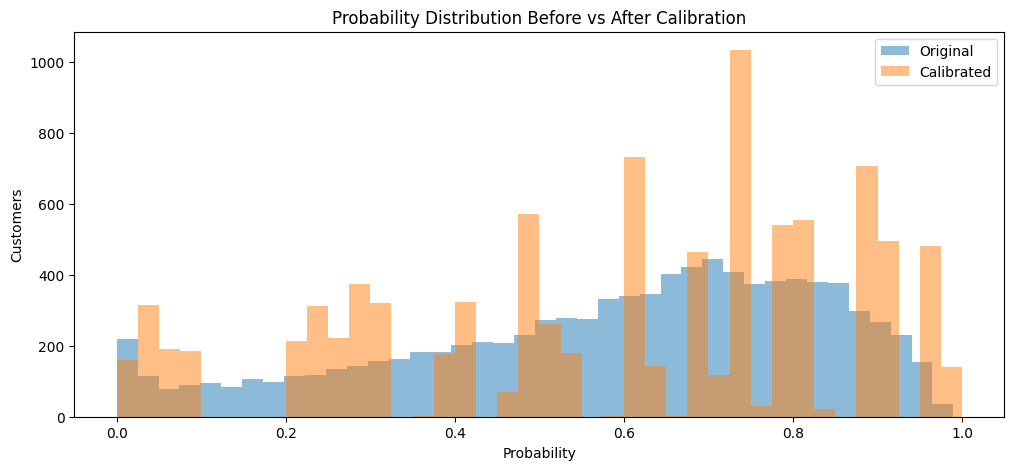

In [23]:
plt.figure(figsize=(12,5))

plt.hist(orig_probs, bins=40, alpha=0.5, label="Original")

plt.hist(cal_probs, bins=40, alpha=0.5, label="Calibrated")

plt.legend()
plt.xlabel("Probability")
plt.ylabel("Customers")
plt.title("Probability Distribution Before vs After Calibration")

plt.show()

###  End of this NOTEBOOK